In [11]:
# CELL 1 — Load every saved result file from Phases 1-6
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
sns.set_style("whitegrid")

with open("phase1_report.json") as f:
    phase1 = json.load(f)
with open("phase2_indian_pines_results.json") as f:
    phase2 = json.load(f)
with open("phase3_pavia_results.json") as f:
    phase3 = json.load(f)
with open("phase4_extension_results.json") as f:
    phase4 = json.load(f)
with open("phase5_ablation_results.json") as f:
    phase5 = json.load(f)
with open("phase5_mcnemar_results.json") as f:
    phase5_mcnemar = json.load(f)
with open("phase6_houston15_results.json") as f:
    phase6 = json.load(f)
with open("phase6_mcnemar_results.json") as f:
    phase6_mcnemar = json.load(f)

print("All result files loaded successfully.")

All result files loaded successfully.


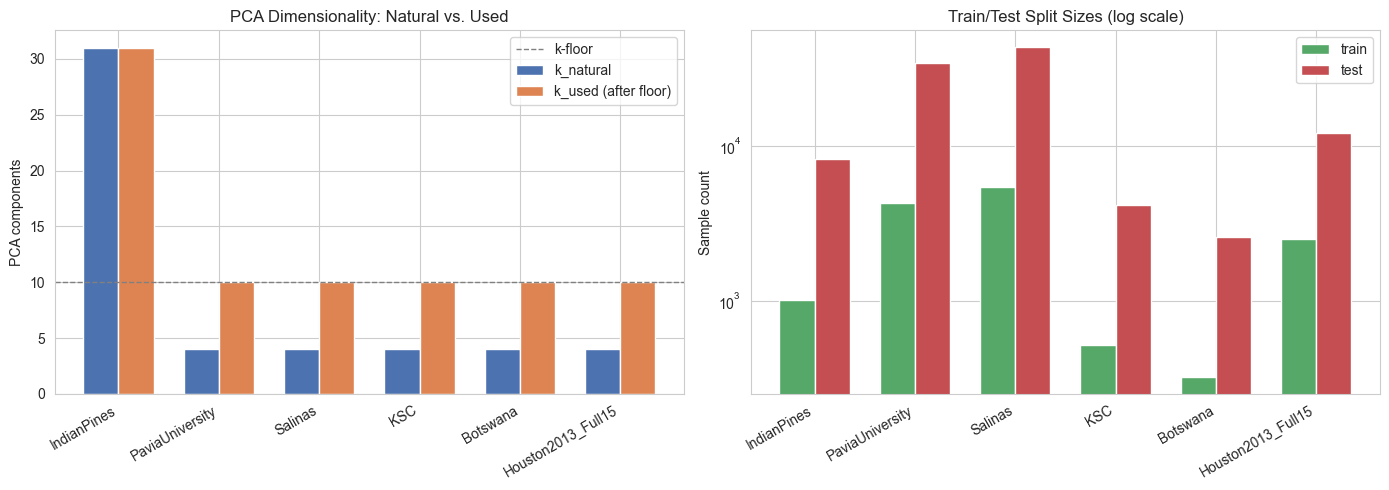

Saved figures/phase1_preprocessing_summary.png


In [2]:
# CELL 2 — Phase 1: per-dataset k_natural vs k_used, and sample sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(phase1.keys())
k_natural = [phase1[n].get("k_natural", 0) for n in names]
k_used = [phase1[n].get("k_used", 0) for n in names]

x = np.arange(len(names))
width = 0.35
axes[0].bar(x - width/2, k_natural, width, label="k_natural", color="#4C72B0")
axes[0].bar(x + width/2, k_used, width, label="k_used (after floor)", color="#DD8452")
axes[0].axhline(y=10, color="gray", linestyle="--", linewidth=1, label="k-floor")
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha="right")
axes[0].set_ylabel("PCA components"); axes[0].set_title("PCA Dimensionality: Natural vs. Used")
axes[0].legend()

n_train = [phase1[n].get("n_train", 0) for n in names]
n_test = [phase1[n].get("n_test", 0) for n in names]
axes[1].bar(x - width/2, n_train, width, label="train", color="#55A868")
axes[1].bar(x + width/2, n_test, width, label="test", color="#C44E52")
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=30, ha="right")
axes[1].set_ylabel("Sample count"); axes[1].set_yscale("log")
axes[1].set_title("Train/Test Split Sizes (log scale)")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/phase1_preprocessing_summary.png", dpi=150)
plt.show()
print("Saved figures/phase1_preprocessing_summary.png")

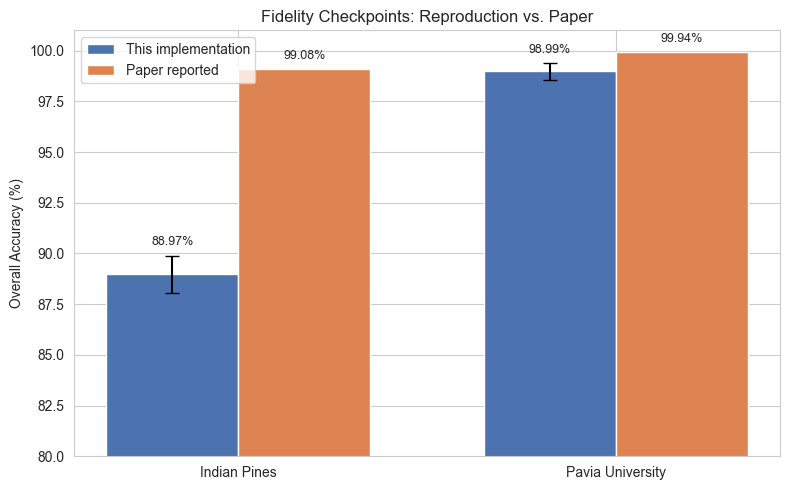

Saved figures/phase2_3_fidelity_checkpoints.png


In [3]:
# CELL 3 — Fidelity checkpoint comparison: your result vs. paper's reported OA
fig, ax = plt.subplots(figsize=(8, 5))

checkpoint_names = ["Indian Pines", "Pavia University"]
your_oa = [phase2["summary"]["OA_mean"] * 100, phase3["summary"]["OA_mean"] * 100]
your_std = [phase2["summary"]["OA_std"] * 100, phase3["summary"]["OA_std"] * 100]
paper_oa = [99.08, 99.94]

x = np.arange(len(checkpoint_names))
width = 0.35
ax.bar(x - width/2, your_oa, width, yerr=your_std, label="This implementation", color="#4C72B0", capsize=5)
ax.bar(x + width/2, paper_oa, width, label="Paper reported", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(checkpoint_names)
ax.set_ylabel("Overall Accuracy (%)")
ax.set_title("Fidelity Checkpoints: Reproduction vs. Paper")
ax.set_ylim(80, 101)
ax.legend()
for i, (y, s) in enumerate(zip(your_oa, your_std)):
    ax.text(i - width/2, y + s + 0.5, f"{y:.2f}%", ha="center", fontsize=9)
for i, y in enumerate(paper_oa):
    ax.text(i + width/2, y + 0.5, f"{y:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/phase2_3_fidelity_checkpoints.png", dpi=150)
plt.show()
print("Saved figures/phase2_3_fidelity_checkpoints.png")

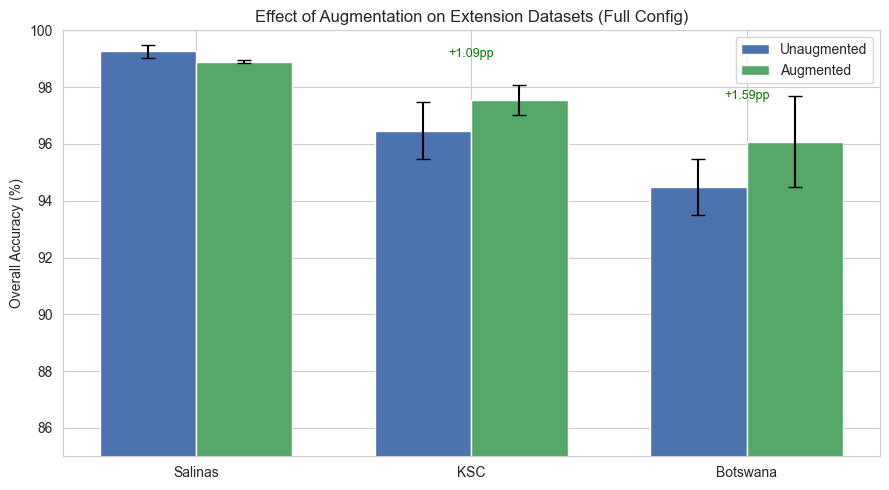

Saved figures/phase4_augmentation_effect.png


In [4]:
# CELL 4 — Augmentation effect across Salinas, KSC, Botswana
fig, ax = plt.subplots(figsize=(9, 5))

ext_names = list(phase4.keys())
unaug_means = [np.mean([r["OA"] for r in phase4[n]["unaugmented"]]) * 100 for n in ext_names]
aug_means = [np.mean([r["OA"] for r in phase4[n]["augmented"]]) * 100 for n in ext_names]
unaug_std = [np.std([r["OA"] for r in phase4[n]["unaugmented"]]) * 100 for n in ext_names]
aug_std = [np.std([r["OA"] for r in phase4[n]["augmented"]]) * 100 for n in ext_names]

x = np.arange(len(ext_names))
width = 0.35
bars1 = ax.bar(x - width/2, unaug_means, width, yerr=unaug_std, label="Unaugmented", color="#4C72B0", capsize=5)
bars2 = ax.bar(x + width/2, aug_means, width, yerr=aug_std, label="Augmented", color="#55A868", capsize=5)

for i, (u, a) in enumerate(zip(unaug_means, aug_means)):
    diff = a - u
    ax.annotate(f"{diff:+.2f}pp", xy=(i, max(u, a) + 1.5), ha="center",
                fontsize=9, color="green" if diff > 0 else "red")

ax.set_xticks(x); ax.set_xticklabels(ext_names)
ax.set_ylabel("Overall Accuracy (%)")
ax.set_title("Effect of Augmentation on Extension Datasets (Full Config)")
ax.set_ylim(85, 100)
ax.legend()
plt.tight_layout()
plt.savefig("figures/phase4_augmentation_effect.png", dpi=150)
plt.show()
print("Saved figures/phase4_augmentation_effect.png")

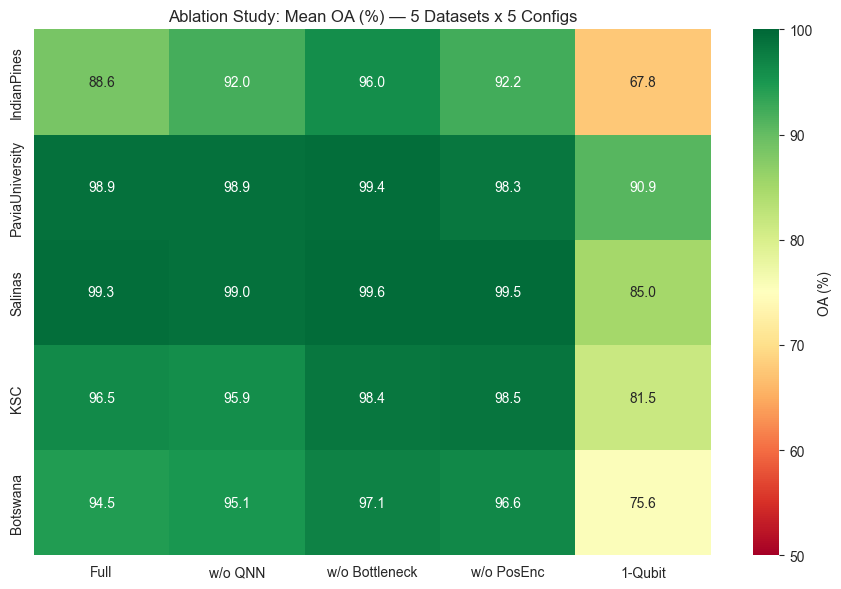

Saved figures/phase5_ablation_heatmap.png


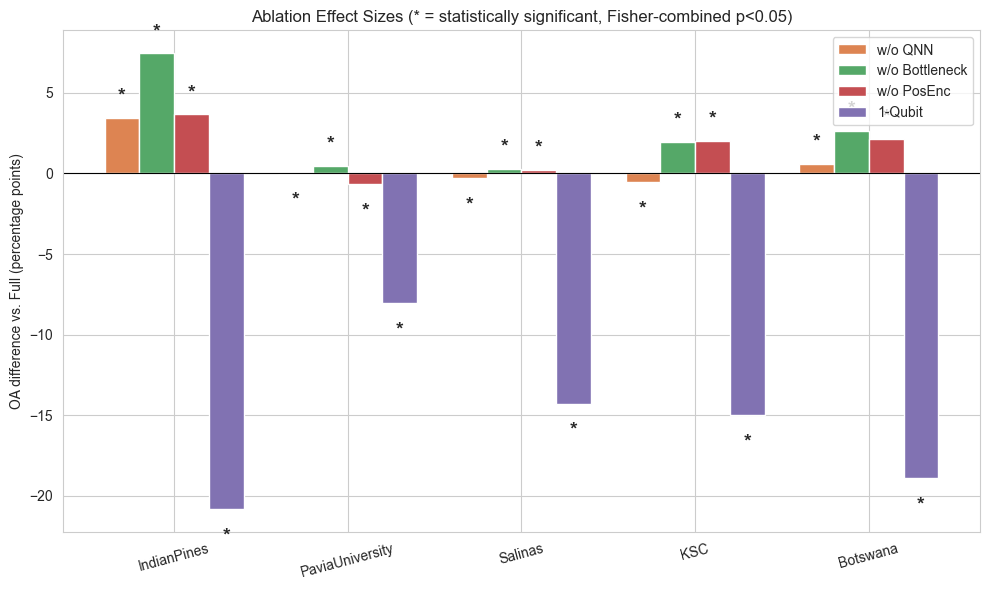

Saved figures/phase5_effect_sizes.png


In [5]:
# CELL 5 — Ablation matrix: mean OA per dataset per config
ablation_datasets = list(phase5.keys())
configs = ["Full", "w/o QNN", "w/o Bottleneck", "w/o PosEnc", "1-Qubit"]

matrix = np.zeros((len(ablation_datasets), len(configs)))
for i, name in enumerate(ablation_datasets):
    for j, config in enumerate(configs):
        matrix[i, j] = np.mean([r["OA"] for r in phase5[name][config]]) * 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="RdYlGn", vmin=50, vmax=100,
            xticklabels=configs, yticklabels=ablation_datasets, ax=ax, cbar_kws={"label": "OA (%)"})
ax.set_title("Ablation Study: Mean OA (%) — 5 Datasets x 5 Configs")
plt.tight_layout()
plt.savefig("figures/phase5_ablation_heatmap.png", dpi=150)
plt.show()
print("Saved figures/phase5_ablation_heatmap.png")

# Effect size relative to Full, with significance markers
fig, ax = plt.subplots(figsize=(10, 6))
comp_configs = ["w/o QNN", "w/o Bottleneck", "w/o PosEnc", "1-Qubit"]
x = np.arange(len(ablation_datasets))
width = 0.2
colors = ["#DD8452", "#55A868", "#C44E52", "#8172B2"]

for j, comp in enumerate(comp_configs):
    effects = []
    for name in ablation_datasets:
        full_oa = np.mean([r["OA"] for r in phase5[name]["Full"]])
        comp_oa = np.mean([r["OA"] for r in phase5[name][comp]])
        effects.append((comp_oa - full_oa) * 100)
    bars = ax.bar(x + (j - 1.5) * width, effects, width, label=comp, color=colors[j])
    for i, e in enumerate(effects):
        sig = phase5_mcnemar[ablation_datasets[i]][comp]["significant"]
        marker = "*" if sig else ""
        ax.text(x[i] + (j - 1.5) * width, e + (1 if e >= 0 else -2), marker,
                ha="center", fontsize=14, fontweight="bold")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(ablation_datasets, rotation=15)
ax.set_ylabel("OA difference vs. Full (percentage points)")
ax.set_title("Ablation Effect Sizes (* = statistically significant, Fisher-combined p<0.05)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/phase5_effect_sizes.png", dpi=150)
plt.show()
print("Saved figures/phase5_effect_sizes.png")

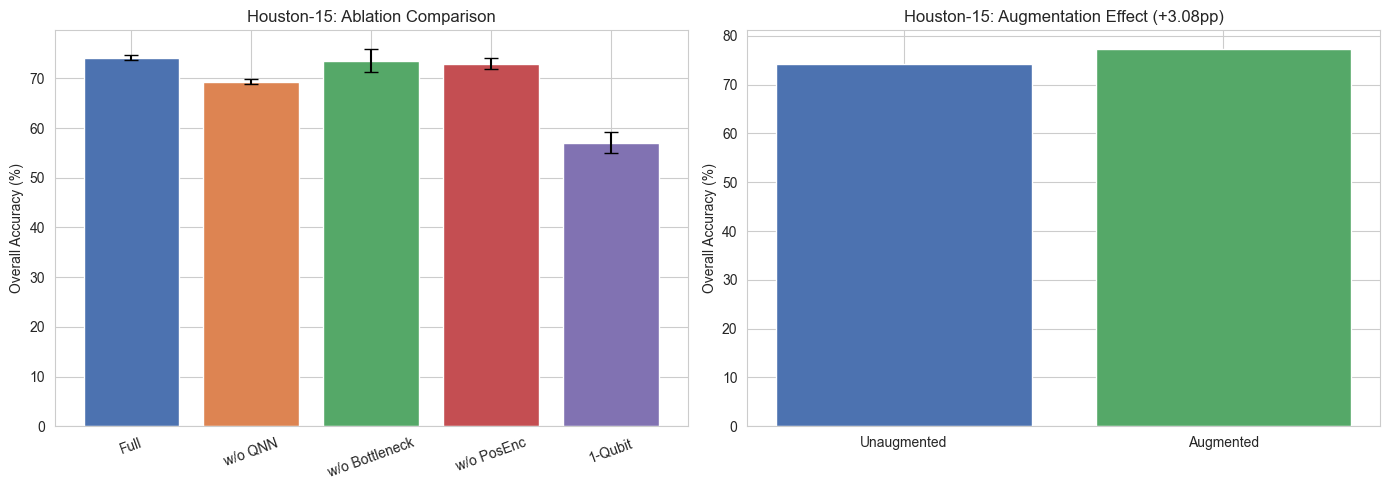

Saved figures/phase6_houston15_summary.png


In [6]:
# CELL 6 — Houston-15: ablation bar chart + augmentation effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h_configs = ["Full", "w/o QNN", "w/o Bottleneck", "w/o PosEnc", "1-Qubit"]
h_means, h_stds = [], []
for c in h_configs:
    vals = phase6[c]["unaugmented"] if c == "Full" else phase6[c]
    oas = [r["OA"] for r in vals]
    h_means.append(np.mean(oas) * 100); h_stds.append(np.std(oas) * 100)

axes[0].bar(h_configs, h_means, yerr=h_stds, capsize=5,
            color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
axes[0].set_ylabel("Overall Accuracy (%)")
axes[0].set_title("Houston-15: Ablation Comparison")
axes[0].tick_params(axis="x", rotation=20)

aug_unaug_oa = np.mean([r["OA"] for r in phase6["Full"]["unaugmented"]]) * 100
aug_aug_oa = np.mean([r["OA"] for r in phase6["Full"]["augmented"]]) * 100
axes[1].bar(["Unaugmented", "Augmented"], [aug_unaug_oa, aug_aug_oa],
            color=["#4C72B0", "#55A868"])
axes[1].set_ylabel("Overall Accuracy (%)")
axes[1].set_title(f"Houston-15: Augmentation Effect (+{aug_aug_oa - aug_unaug_oa:.2f}pp)")

plt.tight_layout()
plt.savefig("figures/phase6_houston15_summary.png", dpi=150)
plt.show()
print("Saved figures/phase6_houston15_summary.png")

In [14]:
# CELL 7 (final) — Confusion matrices for ALL SIX datasets, consistent titling,
# Full QNN-Transformer config, seed 42

from sklearn.metrics import confusion_matrix as sk_confusion_matrix

def plot_confusion(cm, dataset_name, save_path, config="Full QNN-Transformer", seed=42):
    cm = np.array(cm)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    title = f"Confusion Matrix — {dataset_name} {config} (seed {seed})"

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=False, cmap="Blues", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "Proportion"})
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"  saved {save_path}  |  title: \"{title}\"")

print("Generating confusion matrices — consistent naming across all six datasets\n")

# --- Fidelity checkpoints (Phase 2/3 — confusion_matrix saved directly) ---
plot_confusion(phase2["per_seed"][0]["confusion_matrix"],
               "Indian Pines",
               "figures/confmat_indianpines_full.png")

plot_confusion(phase3["per_seed"][0]["confusion_matrix"],
               "Pavia University",
               "figures/confmat_pavia_full.png")

# --- Extension datasets (Phase 5 has no confusion_matrix field saved — reconstructed
# from raw predictions in phase5_ablation_predictions.json + true test labels) ---
with open("phase5_ablation_predictions.json") as f:
    phase5_preds = json.load(f)

for name in ["Salinas", "KSC", "Botswana"]:
    d = np.load(f"preprocessed/{name}.npz")
    true_labels = d["test_labels"] - 1  # match -1 offset used during training
    seed42_preds = np.array(phase5_preds[name]["Full"]["42"])  # JSON keys are strings
    n_classes = int(true_labels.max()) + 1
    cm = sk_confusion_matrix(true_labels, seed42_preds, labels=list(range(n_classes)))
    plot_confusion(cm.tolist(), name,
                   f"figures/confmat_{name.lower()}_full.png")

# --- Houston-15 (Phase 6 — confusion_matrix saved directly) ---
plot_confusion(phase6["Full"]["unaugmented"][0]["confusion_matrix"],
               "Houston 2013 (15-class)",
               "figures/confmat_houston15_full.png")

print("\nAll six confusion matrices regenerated with consistent titles.")

Generating confusion matrices — consistent naming across all six datasets

  saved figures/confmat_indianpines_full.png  |  title: "Confusion Matrix — Indian Pines Full QNN-Transformer (seed 42)"
  saved figures/confmat_pavia_full.png  |  title: "Confusion Matrix — Pavia University Full QNN-Transformer (seed 42)"
  saved figures/confmat_salinas_full.png  |  title: "Confusion Matrix — Salinas Full QNN-Transformer (seed 42)"
  saved figures/confmat_ksc_full.png  |  title: "Confusion Matrix — KSC Full QNN-Transformer (seed 42)"
  saved figures/confmat_botswana_full.png  |  title: "Confusion Matrix — Botswana Full QNN-Transformer (seed 42)"
  saved figures/confmat_houston15_full.png  |  title: "Confusion Matrix — Houston 2013 (15-class) Full QNN-Transformer (seed 42)"

All six confusion matrices regenerated with consistent titles.
